In [67]:
# Reload the modules
%load_ext autoreload
%autoreload 2

# Environment Imports
import torch, torchaudio, numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from scipy.spatial.distance import cdist
from sylber.model.sylber import Sylber
from sylber.utils.segment_utils import get_segment
import importlib, inspect
from pathlib import Path
from sklearn.manifold import TSNE
import ipywidgets as w
import praatio.textgrid as ptg
import librosa.feature
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from IPython.display import display

import testers.params as _params
import testers.evaluation_helpers as _eval
import testers.tuner as _tuner
import testers.cutters as _cutters
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
wav_path = Path("../samples/audio_files/data/09/behav_sub-09_run-01_stim-35_ri_ri_ri_ri_ri_ri_ri_ri_ri.wav")
print("exists:", wav_path.exists())
print("absolute:", wav_path.resolve())

# Load audio and resample to 16 kHz mono
wav, sr = torchaudio.load(wav_path)
wav = torchaudio.functional.resample(wav, sr, 16_000).mean(0, keepdim=True)

# Fetch embeddings
model = Sylber(segment_online=False).eval()
with torch.no_grad():
    states = model.speech_model(wav).last_hidden_state[0].detach().cpu().numpy()

print('Embedding shape:', states.shape)

exists: True
absolute: /Users/sammichaels/Summer 2025 USRA/sylber/samples/audio_files/data/09/behav_sub-09_run-01_stim-35_ri_ri_ri_ri_ri_ri_ri_ri_ri.wav
Embedding shape: (224, 768)


In [4]:
# grab only callables that take (states, …) and return a list/tuple
cutters = importlib.reload(_cutters)
EXCLUDE = {"get_segment"}

CUT_FUNCS = {
    name: fn
    for name, fn in inspect.getmembers(cutters, inspect.isfunction)
    if fn.__code__.co_varnames[:1] == ('states',) and name not in EXCLUDE
}

print("Loaded cutters:", list(CUT_FUNCS))

Loaded cutters: ['bocpd_offline', 'dbscan_segmentation', 'energy_drop', 'energy_knee_segmentation', 'foote_novelty', 'ruptures_pelt', 'spectral_flux_segmentation', 'sylber_greedy', 'uniform_segmentation']


In [5]:
# ------------------------------------------------------------------
# Rename WAV files: " "  →  "_"
# ------------------------------------------------------------------

AUDIO_ROOT = Path("../samples/audio_files/data/09")      # adjust if needed
count = 0

for wav in AUDIO_ROOT.rglob("*.wav"):                    # walk sub-dirs too
    new_name = wav.name.replace(" ", "_")
    if new_name == wav.name:
        continue                                         # already OK
    new_path = wav.with_name(new_name)
    print(f"{wav.name}  →  {new_name}")
    wav.rename(new_path)
    count += 1

print(f"\nRenamed {count} WAV file(s).")


Renamed 0 WAV file(s).


In [74]:
project_root = Path().resolve().parent

# (B) Point to the correct folders
WAV_DIR = project_root / "samples" / "audio_files" / "data"
TG_DIR  = WAV_DIR / "TextGrid"

print("Looking for WAVs under:", WAV_DIR)
print("Looking for TextGrids under:", TG_DIR)

# (C) Recursively find all .wav files but skip anything in TextGrid/
wav_paths = sorted([p for p in WAV_DIR.rglob("*.wav") if "TextGrid" not in p.parts])
print(f"Found {len(wav_paths)} WAV(s) under {WAV_DIR} (excluding TextGrid).")

# (D) Recursively find all .TextGrid files
tg_paths = sorted(TG_DIR.rglob("*.TextGrid"))
print(f"Found {len(tg_paths)} TextGrid(s) under {TG_DIR}.")

# Build a dict: stem -> TextGrid path
tg_by_stem = {tg.stem: tg for tg in tg_paths}

clips = []
for wav_path in wav_paths:
    stem = wav_path.stem

    if stem not in tg_by_stem:
        print(f"  ▶ No TextGrid for '{stem}', skipping.")
        continue

    # 1) Load audio
    wav_signal, sr = librosa.load(str(wav_path), sr=None)

    # 2) Load boundary start times from TextGrid (using the updated signature)
    #    If load_textgrid_times has signature (path, tier_name="syll"):
    ref_times = _eval.load_textgrid_times(tg_by_stem[stem], tier_name="syll")
    #    If it only accepts a single argument (path), then use:
    # ref_times = load_textgrid_times(tg_by_stem[stem])

    # 3) Compute “states” (Mel-spectrogram transpose as a placeholder)
    S = librosa.feature.melspectrogram(y=wav_signal, sr=sr)
    states = S.T

    clips.append((wav_path, ref_times, wav_signal, states))

print(f"\nBuilt clips list with {len(clips)} files.")
if clips:
    first_wav, first_ref, first_wav_signal, first_states = clips[0]
    print(
        "Example entry (first clip):",
        first_wav.name,
        ", #frames =", first_states.shape[0]
    )

Looking for WAVs under: /Users/sammichaels/Summer 2025 USRA/sylber/samples/audio_files/data
Looking for TextGrids under: /Users/sammichaels/Summer 2025 USRA/sylber/samples/audio_files/data/TextGrid
Found 168 WAV(s) under /Users/sammichaels/Summer 2025 USRA/sylber/samples/audio_files/data (excluding TextGrid).
Found 42 TextGrid(s) under /Users/sammichaels/Summer 2025 USRA/sylber/samples/audio_files/data/TextGrid.
  ▶ No TextGrid for 'behav_sub-03_run-01_stim-01_cri ti cal prac ti cal po ta to', skipping.
  ▶ No TextGrid for 'behav_sub-03_run-01_stim-02_ti ti ti ti ti ti ti ti ti', skipping.
  ▶ No TextGrid for 'behav_sub-03_run-01_stim-03_po ta to cri ti cal prac ti cal', skipping.
  ▶ No TextGrid for 'behav_sub-03_run-01_stim-04_prac ti cal po ta to cri ti cal', skipping.
  ▶ No TextGrid for 'behav_sub-03_run-01_stim-05_prac prac prac prac prac prac prac prac prac', skipping.
  ▶ No TextGrid for 'behav_sub-03_run-01_stim-06_po po po po po po po po po', skipping.
  ▶ No TextGrid for 'be

In [24]:
search_space = _params.get_space(tiny=False)

for algo, grid in search_space.items():
    print(algo, "→", grid)

foote_novelty → {'ker_win': [4, 6, 8, 10, 12, 16, 20, 24, 28, 32], 'peak_thr': [0.8, 1.0, 1.2, 1.5, 1.8, 2.0, 2.5, 3.0]}
bocpd_offline → {'lam': [25, 50, 100, 200, 400], 'thresh': [0.2, 0.35, 0.5, 0.65, 0.8]}
ruptures_pelt → {'model': ['rbf', 'l2'], 'penalty': [1, 3, 5, 10], 'min_size': [1, 5, 10], 'jump': [1, 5, 10]}
dbscan_segmentation → {'eps': [0.3, 0.5, 0.7], 'min_samples': [3, 5, 10], 'metric': ['cosine', 'euclidean']}
spectral_flux → {'sr': [16000], 'flux_thr': [0.05, 0.1, 0.2], 'min_dist': [3, 5, 10], 'hop_length': [256, 512]}
energy_knee → {'smoothing': [3, 5, 10]}
uniform_segmentation → {'seg_len': [25, 50, 100]}


In [25]:
df_all = _tuner.tune_all(search_space, clips, tol=0.02)

# 2.2 Show the top‐10 rows by mean F₁ (across all algorithms & hyperparameters)
print("Top 10 overall (all cutters):")
df_all.head(10)

→ Running grid for 'bocpd_offline' with params: {'lam': [25, 50, 100, 200, 400], 'thresh': [0.2, 0.35, 0.5, 0.65, 0.8]}
→ Running grid for 'bocpd_offline' combo 1/25 with params: {'lam': 25, 'thresh': 0.2}


/opt/homebrew/Caskroom/miniconda/base/envs/sylber/lib/python3.10/site-packages/bayesian_changepoint_detection/offline_changepoint_detection.py:97: RuntimeWarning: invalid value encountered in log
  antiG = np.log(-G[n-1-t])


    • bocpd_offline   combo 1/25 clip 10/42 → (frames: 388, this clip: 3.65s, since combo start: 38.10s)
    • bocpd_offline   combo 1/25 clip 20/42 → (frames: 388, this clip: 3.57s, since combo start: 74.69s)
    • bocpd_offline   combo 1/25 clip 30/42 → (frames: 388, this clip: 3.68s, since combo start: 111.63s)
    • bocpd_offline   combo 1/25 clip 40/42 → (frames: 388, this clip: 3.62s, since combo start: 148.87s)
    • bocpd_offline   combo 1/25 clip 42/42 → (frames: 388, this clip: 3.73s, since combo start: 156.11s)
○ Finished combo 1/25 in 156.1s,  f_mean = 0.128

→ Running grid for 'bocpd_offline' combo 2/25 with params: {'lam': 25, 'thresh': 0.35}
    • bocpd_offline   combo 2/25 clip 10/42 → (frames: 388, this clip: 3.68s, since combo start: 37.16s)
    • bocpd_offline   combo 2/25 clip 20/42 → (frames: 388, this clip: 3.65s, since combo start: 74.09s)
    • bocpd_offline   combo 2/25 clip 30/42 → (frames: 388, this clip: 3.73s, since combo start: 111.23s)
    • bocpd_offline

,algo,lam,thresh,f_mean,f_std,t_mean,mem_mean,eps,min_samples,metric,ker_win,peak_thr,model,penalty,min_size,jump,seg_len
123,ruptures_pelt,NaN,NaN,0.165046,0.057210,0.176668,0.004012,NaN,NaN,NaN,NaN,NaN,rbf,1.0,1.0,1.0,NaN
124,ruptures_pelt,NaN,NaN,0.162925,0.063909,0.136981,0.003230,NaN,NaN,NaN,NaN,NaN,rbf,1.0,5.0,1.0,NaN
125,ruptures_pelt,NaN,NaN,0.161897,0.081784,0.005005,0.001019,NaN,NaN,NaN,NaN,NaN,rbf,1.0,10.0,10.0,NaN
127,ruptures_pelt,NaN,NaN,0.161030,0.081665,0.005047,0.001035,NaN,NaN,NaN,NaN,NaN,rbf,1.0,5.0,10.0,NaN
126,ruptures_pelt,NaN,NaN,0.161030,0.081665,0.005153,0.001035,NaN,NaN,NaN,NaN,NaN,rbf,1.0,1.0,10.0,NaN
128,ruptures_pelt,NaN,NaN,0.153077,0.076820,0.011938,0.001792,NaN,NaN,NaN,NaN,NaN,rbf,1.0,5.0,5.0,NaN
129,ruptures_pelt,NaN,NaN,0.152395,0.076734,0.012475,0.001746,NaN,NaN,NaN,NaN,NaN,rbf,1.0,1.0,5.0,NaN
130,ruptures_pelt,NaN,NaN,0.151596,0.063566,0.024953,0.002056,NaN,NaN,NaN,NaN,NaN,rbf,3.0,10.0,5.0,NaN
132,ruptures_pelt,NaN,NaN,0.150989,0.063527,0.024771,0.002077,NaN,NaN,NaN,NaN,NaN,rbf,3.0,1.0,5.0,NaN
131,ruptures_pelt,NaN,NaN,0.150989,0.063527,0.024983,0.002079,NaN,NaN,NaN,NaN,NaN,rbf,3.0,5.0,5.0,NaN


In [26]:
df_all.to_csv("tuning_results.csv", index=False)

In [35]:
!head -n 5 "../testers/tuning_results.csv"

df = pd.read_csv("../testers/tuning_results.csv")

# 2) Sanity check
print("Columns:", df.columns.tolist())
print("Algorithms:", df["algo"].unique())


algo,lam,thresh,f_mean,f_std,t_mean,mem_mean,eps,min_samples,metric,ker_win,peak_thr,model,penalty,min_size,jump,seg_len
ruptures_pelt,,,0.16504596394209373,0.05721007347159916,0.1766682955938103,0.0040118809523809525,,,,,,rbf,1.0,1.0,1.0,
ruptures_pelt,,,0.1629247057292248,0.06390945856007879,0.13698126483775144,0.0032301190476190476,,,,,,rbf,1.0,5.0,1.0,
ruptures_pelt,,,0.16189712968050848,0.081783715224758,0.005004628878807472,0.0010187619047619047,,,,,,rbf,1.0,10.0,10.0,
ruptures_pelt,,,0.16102989381737154,0.08166478320611904,0.005046510924806907,0.001034738095238095,,,,,,rbf,1.0,5.0,10.0,
Columns: ['algo', 'lam', 'thresh', 'f_mean', 'f_std', 't_mean', 'mem_mean', 'eps', 'min_samples', 'metric', 'ker_win', 'peak_thr', 'model', 'penalty', 'min_size', 'jump', 'seg_len']
Algorithms: ['ruptures_pelt' 'foote_novelty' 'dbscan_segmentation'
 'uniform_segmentation' 'bocpd_offline']



→ foote_novelty: 80 rows found
   → 80 → 80 after dropping NaNs
   plotting columns: ['ker_win', 'peak_thr', 'f_mean', 't_mean', 'mem_mean']


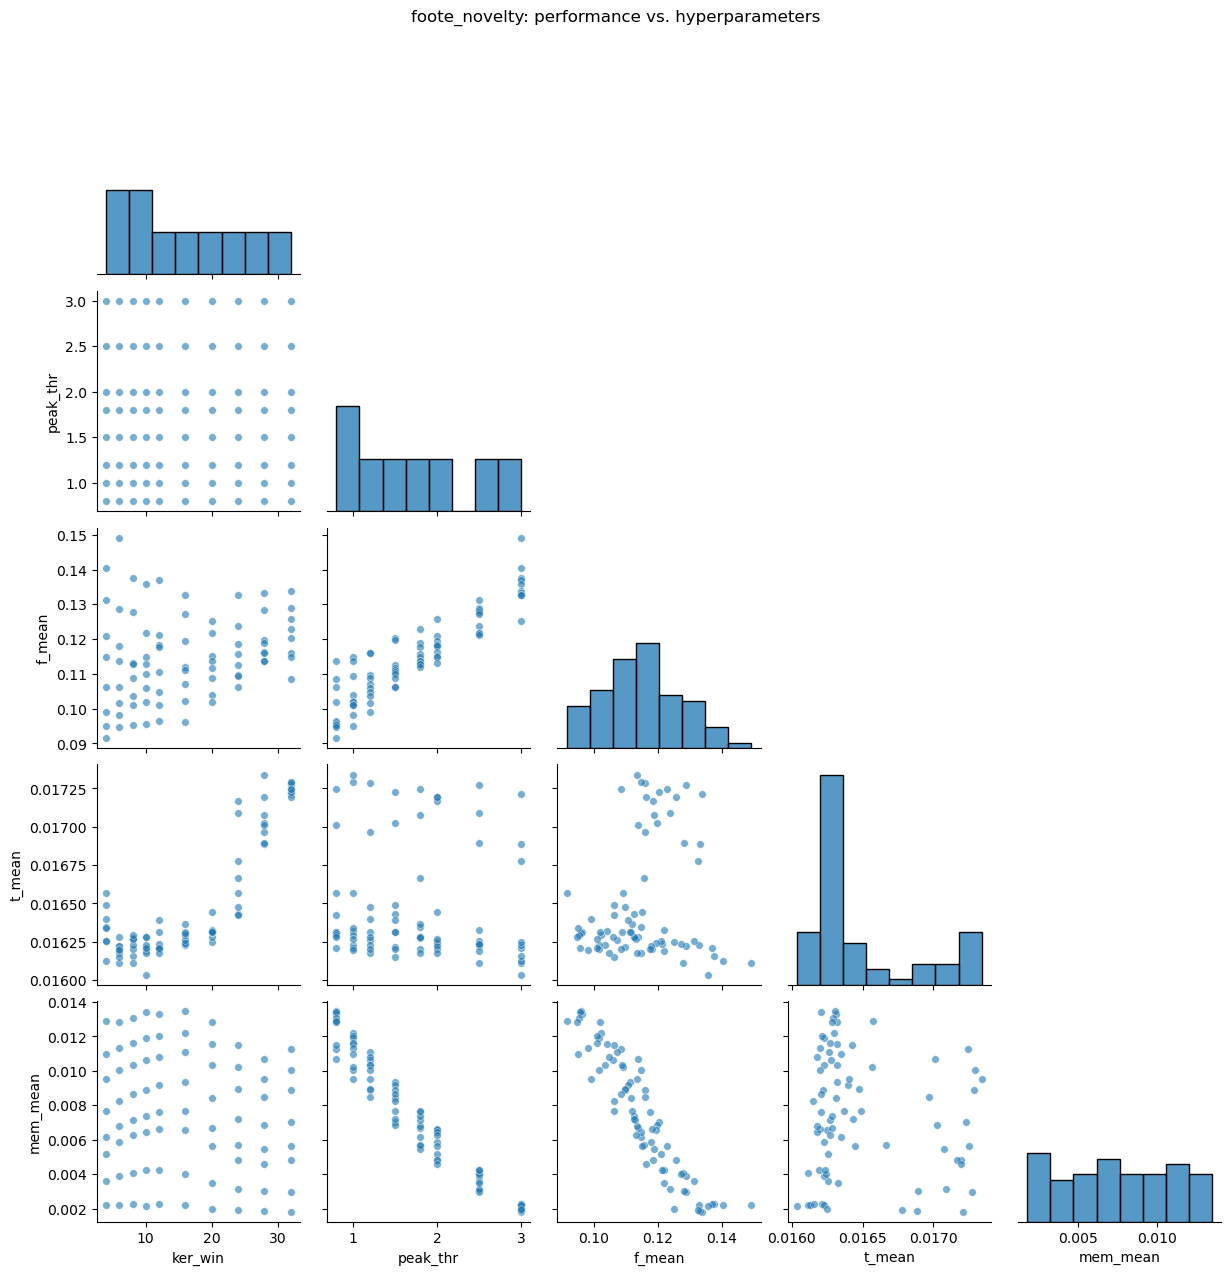


→ energy_drop: 0 rows found

→ sylber_greedy: 0 rows found

→ bocpd_offline: 25 rows found
   → 25 → 25 after dropping NaNs
   plotting columns: ['lam', 'thresh', 'f_mean', 't_mean', 'mem_mean']


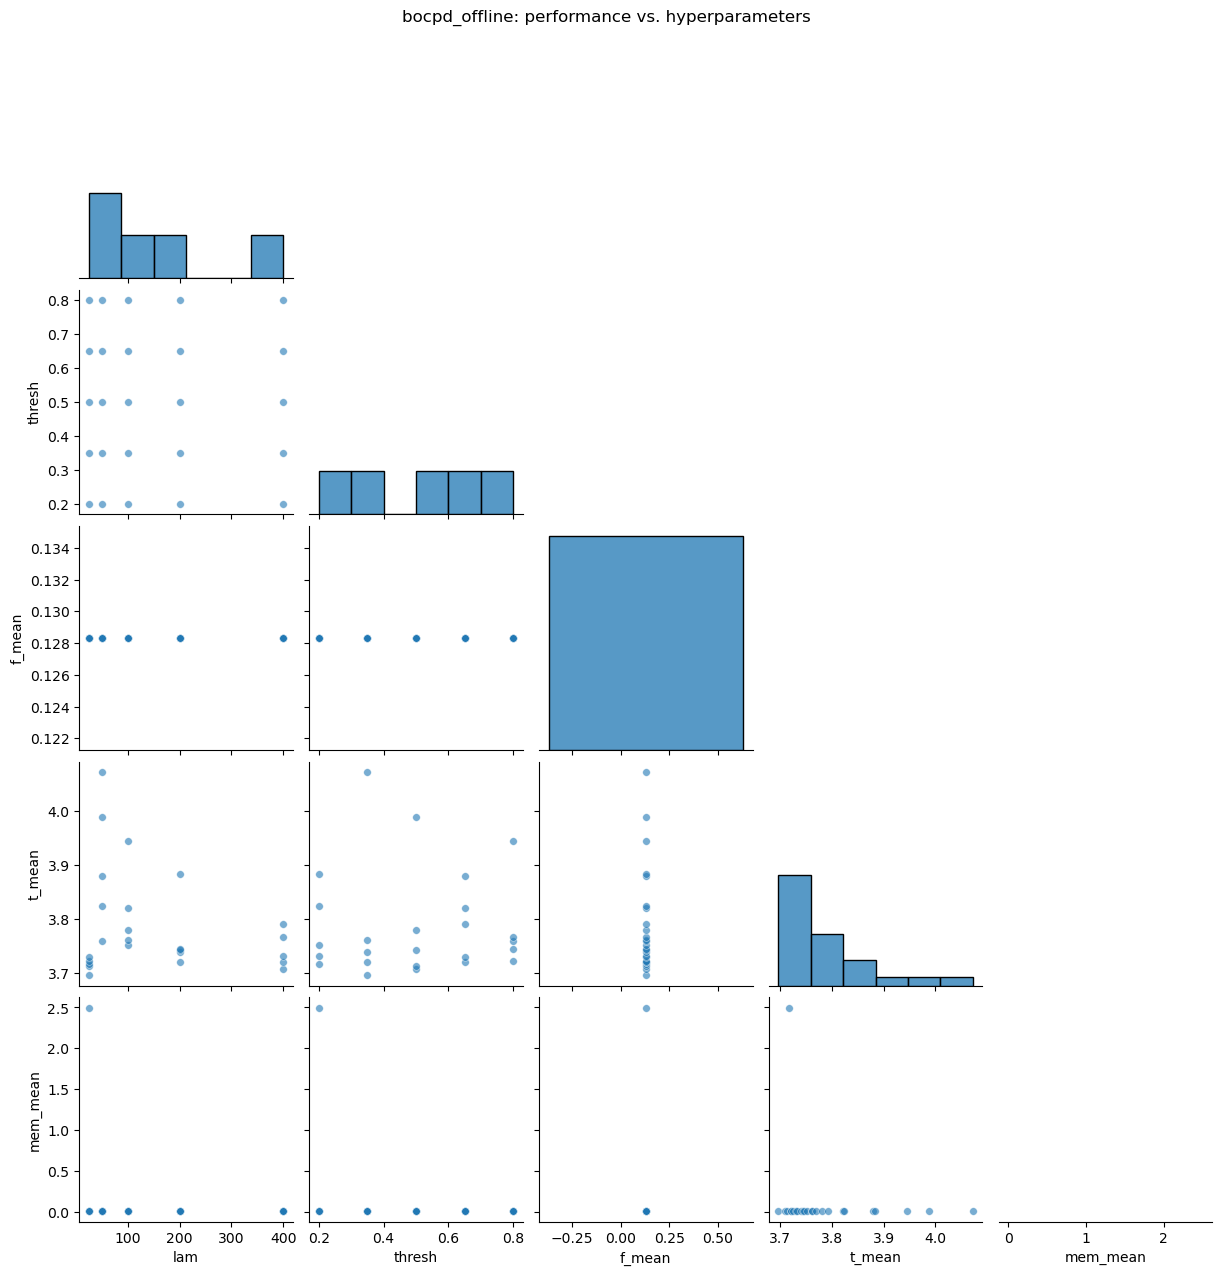


→ dbscan_segmentation: 18 rows found
   → 18 → 18 after dropping NaNs
   plotting columns: ['eps', 'min_samples', 'f_mean', 't_mean', 'mem_mean']


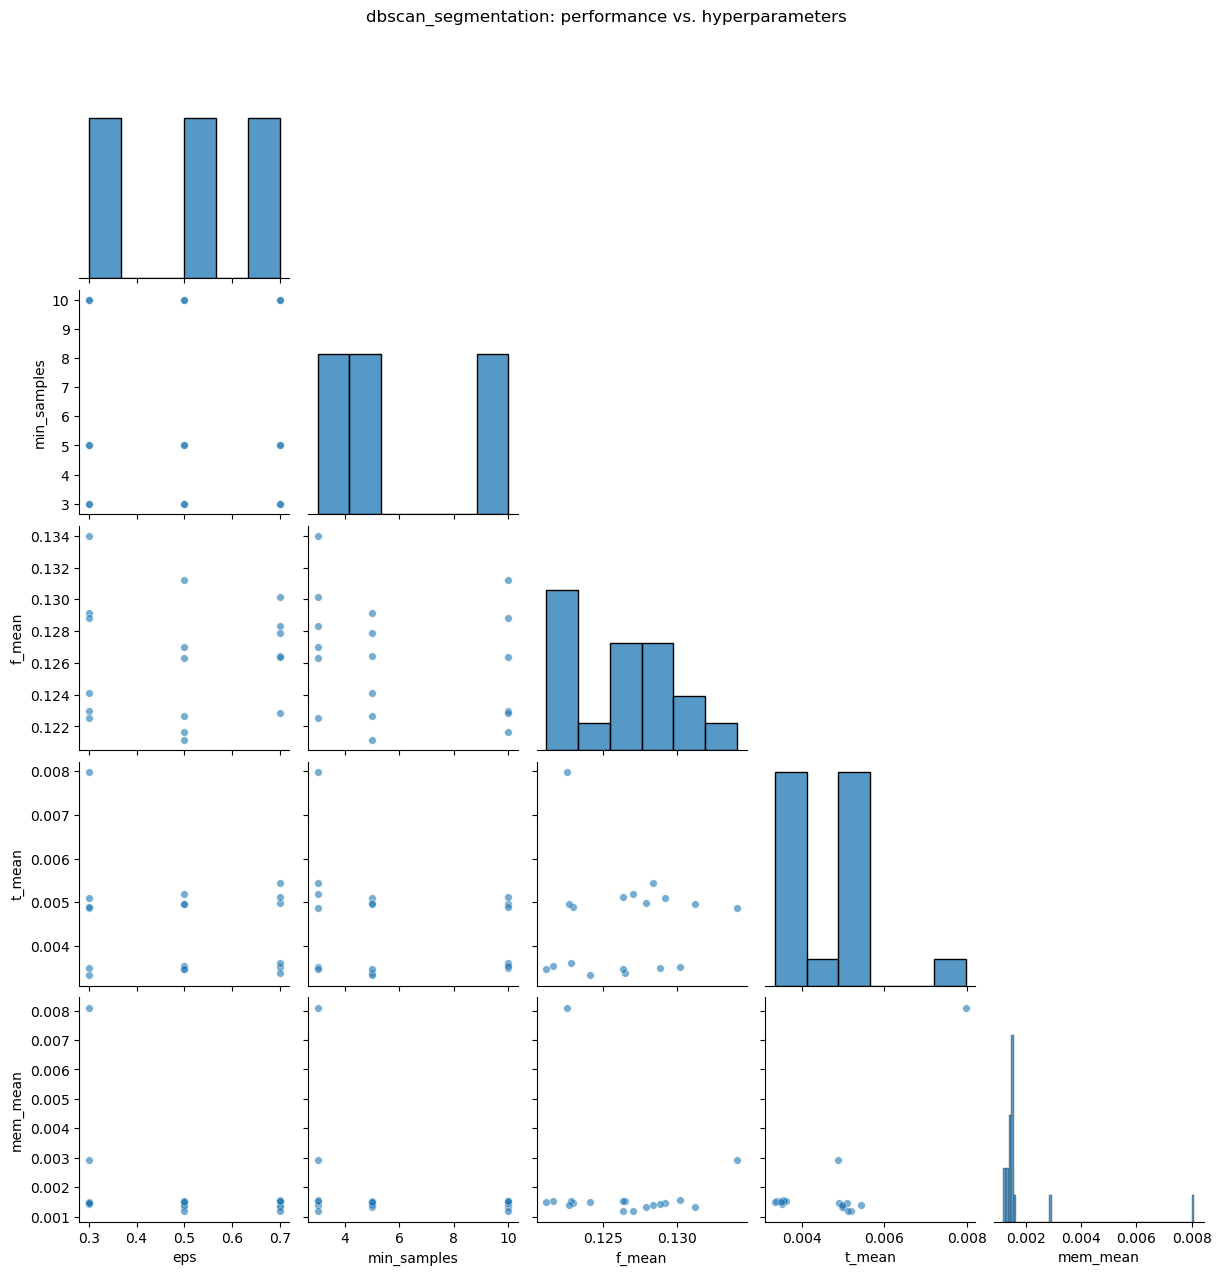


→ uniform_segmentation: 3 rows found
   → 3 → 3 after dropping NaNs
   plotting columns: ['seg_len', 'f_mean', 't_mean', 'mem_mean']


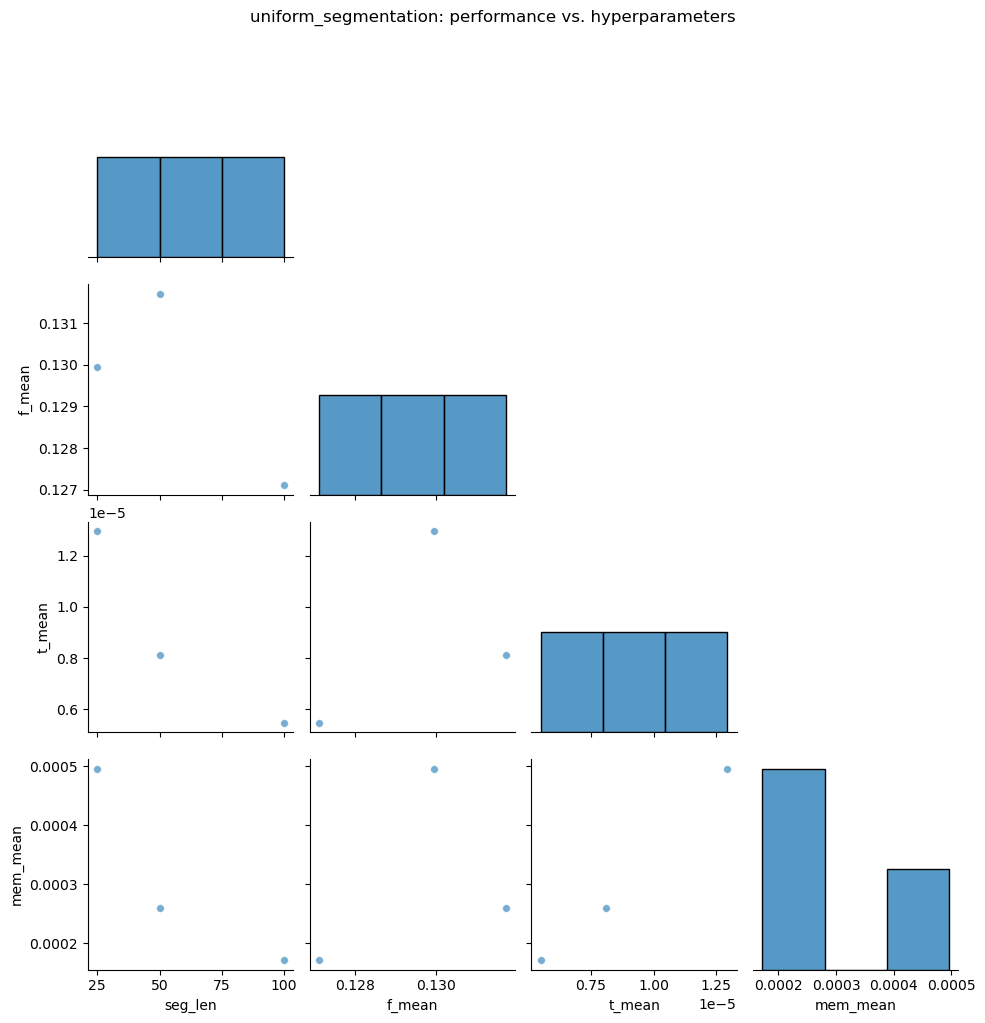


→ ruptures_pelt: 72 rows found
   → 72 → 72 after dropping NaNs
   plotting columns: ['penalty', 'min_size', 'jump', 'f_mean', 't_mean', 'mem_mean']


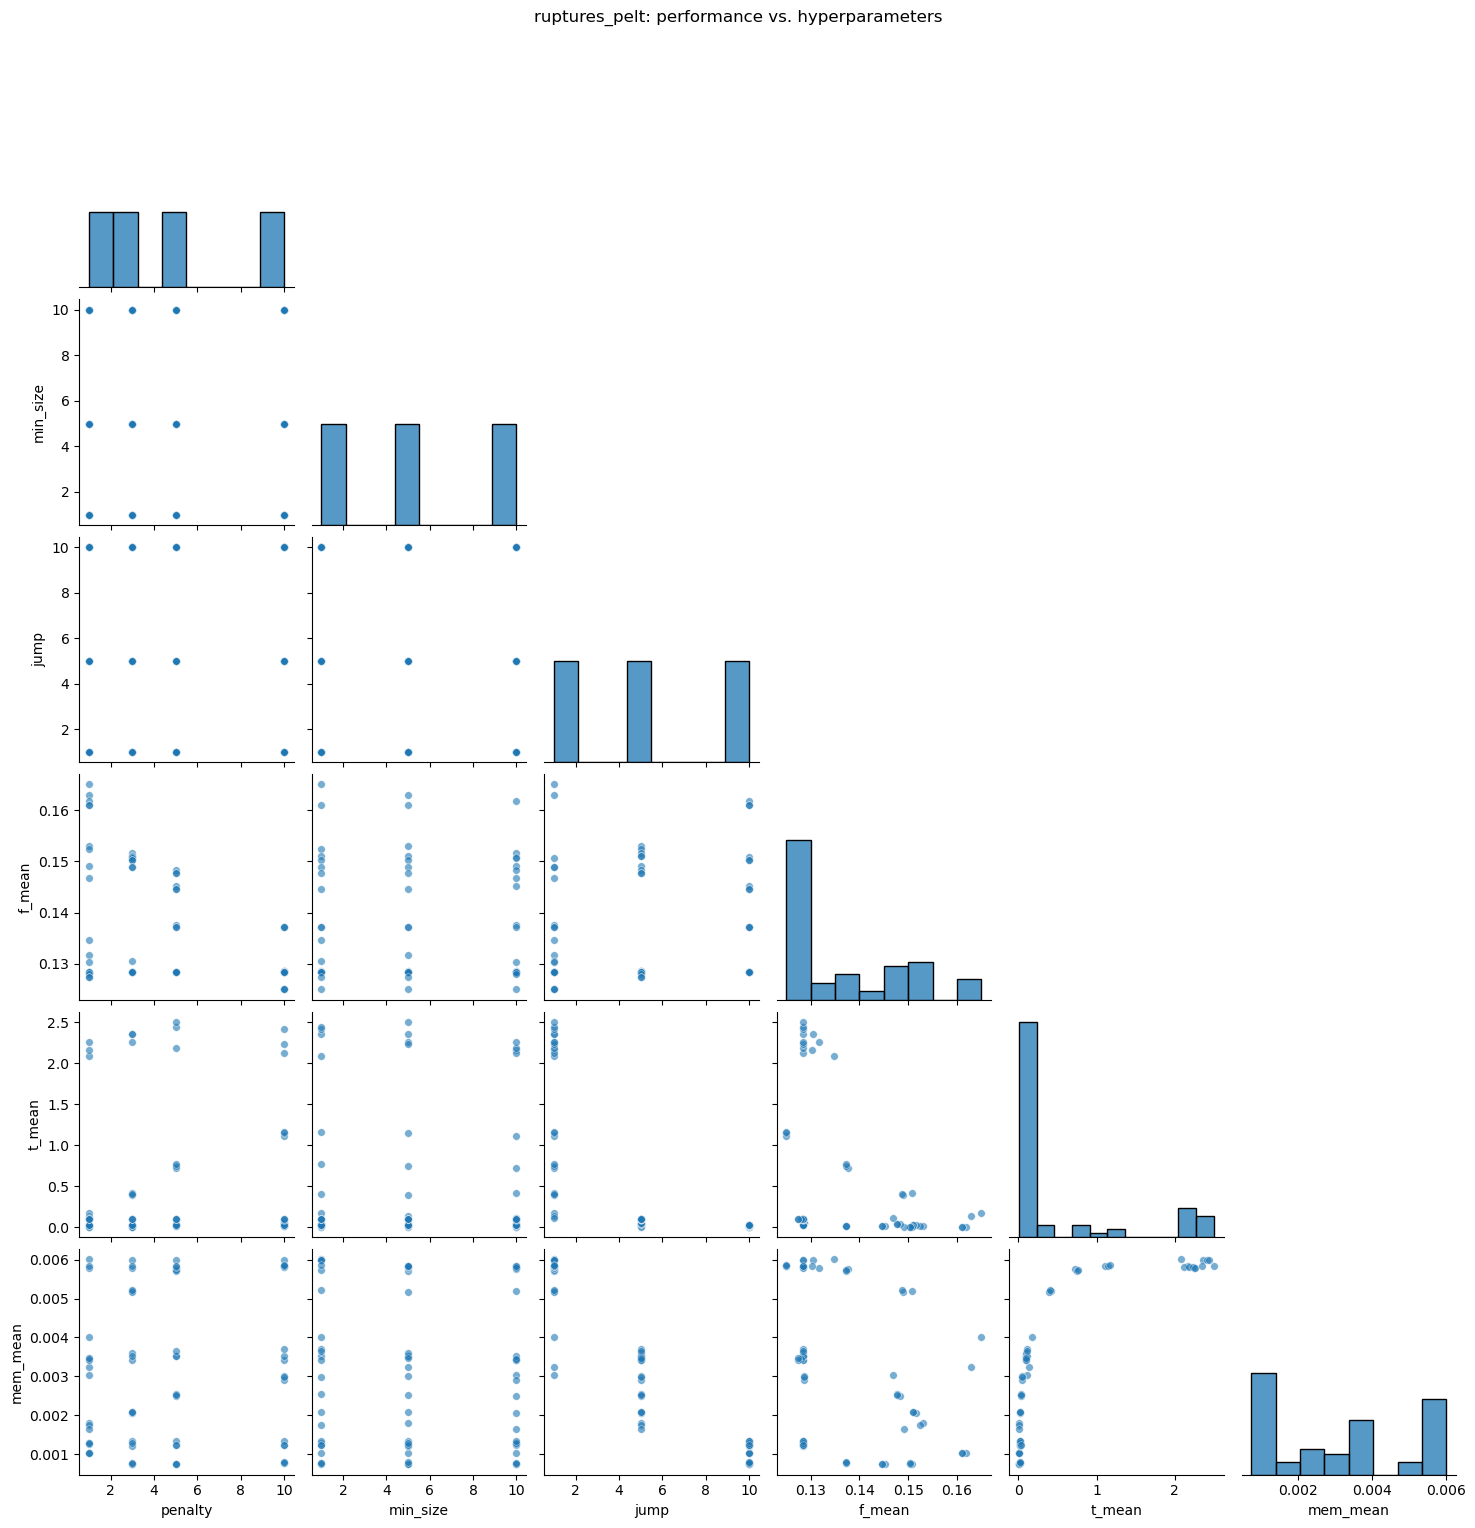

In [36]:
hyper_map = {
    'foote_novelty':       ['ker_win','peak_thr'],
    'energy_drop':         ['threshold_db','min_len'],
    'sylber_greedy':       ['norm_thr','merge_thr'],
    'bocpd_offline':       ['lam','thresh'],
    'dbscan_segmentation': ['eps','min_samples'],
    'uniform_segmentation':['seg_len'],
    'ruptures_pelt':       ['penalty','min_size','jump'],
}

# 4) Loop through each algorithm and plot its pairplot
for algo, params in hyper_map.items():
    sub = df[df['algo'] == algo].copy()
    print(f"\n→ {algo}: {len(sub)} rows found")
    if sub.empty:
        continue

    # Coerce to numeric and drop rows missing all hyperparams
    for c in params + ['f_mean','t_mean','mem_mean']:
        sub[c] = pd.to_numeric(sub[c], errors='coerce')
    before = len(sub)
    sub = sub.dropna(subset=params, how='all')
    after = len(sub)
    print(f"   → {before} → {after} after dropping NaNs")

    if sub.empty:
        print("   (no valid rows, skipping)")
        continue

    cols = params + ['f_mean','t_mean','mem_mean']
    print("   plotting columns:", cols)

    grid = sns.pairplot(
        sub,
        vars=cols,
        corner=True,
        plot_kws={'alpha':0.6, 's':30}
    )
    grid.fig.suptitle(f"{algo}: performance vs. hyperparameters", y=1.02)
    plt.show()


→ foote_novelty: plotting 2-D surface on 80 combos


/opt/homebrew/Caskroom/miniconda/base/envs/sylber/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  fig.canvas.draw()
/var/folders/yc/_16zw8rd27z9wgxd6pspkcqc0000gn/T/ipykernel_99526/1680424649.py:43: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniconda/base/envs/sylber/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


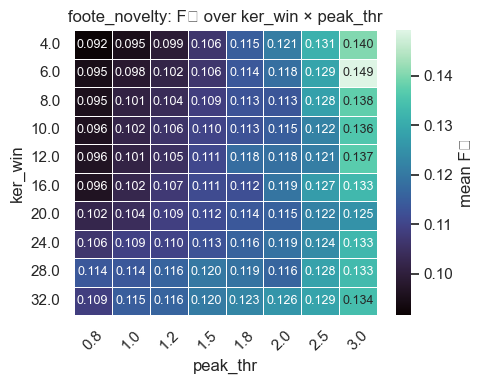


→ bocpd_offline: plotting 2-D surface on 25 combos


/opt/homebrew/Caskroom/miniconda/base/envs/sylber/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  fig.canvas.draw()
/var/folders/yc/_16zw8rd27z9wgxd6pspkcqc0000gn/T/ipykernel_99526/1680424649.py:43: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniconda/base/envs/sylber/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


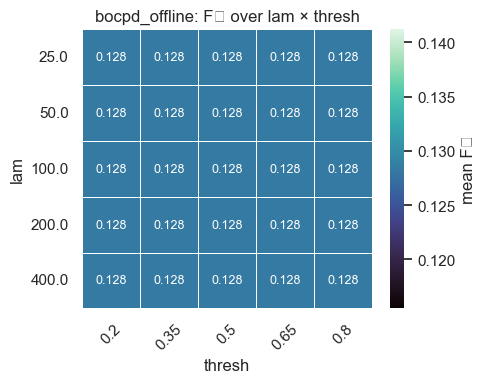


→ dbscan_segmentation: plotting 2-D surface on 18 combos


/opt/homebrew/Caskroom/miniconda/base/envs/sylber/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  fig.canvas.draw()
/var/folders/yc/_16zw8rd27z9wgxd6pspkcqc0000gn/T/ipykernel_99526/1680424649.py:43: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniconda/base/envs/sylber/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


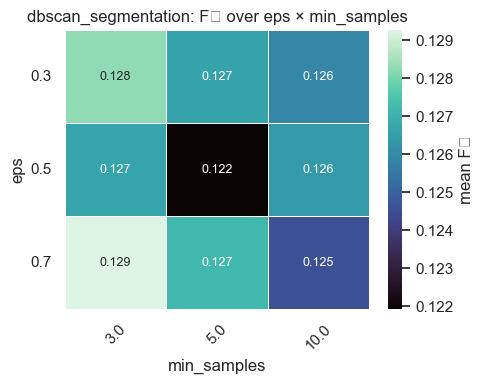

/var/folders/yc/_16zw8rd27z9wgxd6pspkcqc0000gn/T/ipykernel_99526/1680424649.py:19: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  plt.tight_layout()



→ uniform_segmentation: plotting 1-D surface on 3 combos


/opt/homebrew/Caskroom/miniconda/base/envs/sylber/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


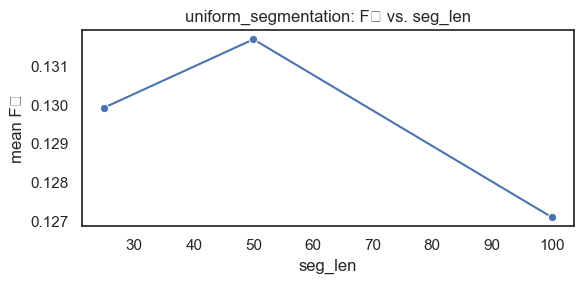


→ ruptures_pelt: plotting 3-D surface on 72 combos


/opt/homebrew/Caskroom/miniconda/base/envs/sylber/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


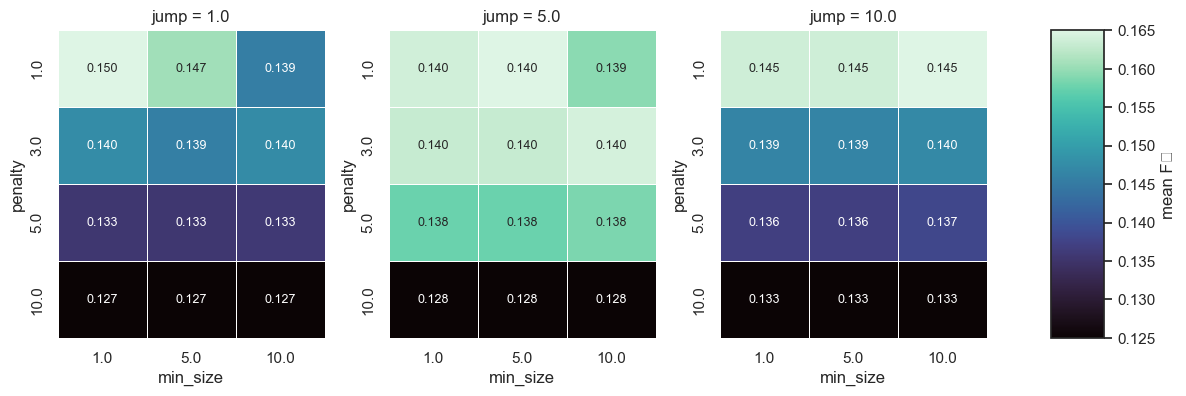

In [48]:
for algo, params in hyper_map.items():
    sub = df[df['algo']==algo].copy()
    if sub.empty:
        continue

    # coerce performance + hyperparams to numeric
    for c in params + ['f_mean']:
        sub[c] = pd.to_numeric(sub[c], errors='coerce')

    print(f"\n→ {algo}: plotting {len(params)}-D surface on {len(sub)} combos")

    # 1D case: line plot
    if len(params) == 1:
        p = params[0]
        plt.figure(figsize=(6,3))
        sns.lineplot(x=p, y='f_mean', data=sub, marker='o')
        plt.title(f"{algo}: F₁ vs. {p}")
        plt.ylabel("mean F₁")
        plt.tight_layout()
        plt.show()

    # 2D case: heatmap
    elif len(params) == 2:
        p1, p2 = params
        sub2 = sub.dropna(subset=[p1,p2], how='all')
        pivot = sub2.pivot_table(
            index=p1, columns=p2, values='f_mean', aggfunc='mean'
        )
        plt.figure(figsize=(5,4))
        sns.heatmap(
            pivot,
            annot=True, fmt=".3f",
            cmap="mako",
            cbar_kws={'label':'mean F₁'},
            linewidths=0.6, linecolor="white",
            annot_kws={'fontsize':9},
        )
        plt.title(f"{algo}: F₁ over {p1} × {p2}")
        plt.xlabel(p2)
        plt.ylabel(p1)
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

    # 3D case: one heatmap per slice of the 3rd param
    elif len(params) == 3:
        sub = df[df['algo']=='ruptures_pelt'].copy()
        for c in ['penalty','min_size','jump','f_mean']:
            sub[c] = pd.to_numeric(sub[c], errors='coerce')
        
        jumps = sorted(sub['jump'].dropna().unique())
        n = len(jumps)
        
        # 1) Create a GridSpec: n columns for heatmaps + 1 narrow column for colorbar
        fig = plt.figure(figsize=(4*n + 1.5, 4))
        gs = GridSpec(1, n+1, width_ratios=[1]*n + [0.2], wspace=0.3)
        
        # 2) Draw each heatmap into gs[0, i]
        axes = []
        for i, j in enumerate(jumps):
            ax = fig.add_subplot(gs[0, i])
            slice_df = sub[sub['jump']==j]
            pivot = slice_df.pivot_table(
                index='penalty', columns='min_size', values='f_mean', aggfunc='mean'
            )
            sns.heatmap(
                pivot, ax=ax,
                annot=True, fmt=".3f",
                cmap="mako",
                cbar=False,
                linewidths=0.6, linecolor="white",
                annot_kws={'fontsize':9}
            )
            ax.set_title(f"jump = {j}")
            ax.set_xlabel("min_size")
            axes.append(ax)
        
        axes[0].set_ylabel("penalty")
        
        # 3) Create a ScalarMappable and put its colorbar into the *last* GridSpec cell
        sm = ScalarMappable(
            cmap="mako",
            norm=Normalize(vmin=sub['f_mean'].min(), vmax=sub['f_mean'].max())
        )
        sm.set_array([])
        
        cax = fig.add_subplot(gs[0, -1])
        fig.colorbar(sm, cax=cax, orientation="vertical")
        cax.set_ylabel("mean F₁")
        
        plt.show()

    else:
        print(f"I don’t know how to visualize {len(params)}-D for {algo}")

In [50]:
best_idx = df.groupby("algo")["f_mean"].idxmax()

best_per_algo = df.loc[best_idx].reset_index(drop=True)

best_per_algo = best_per_algo.sort_values("algo")

best_per_algo.to_csv("../testers/Best_Hyperparameters_per_Algorithm.csv", index=False)

display(best_per_algo)

,algo,lam,thresh,f_mean,f_std,t_mean,mem_mean,eps,min_samples,metric,ker_win,peak_thr,model,penalty,min_size,jump,seg_len
0,bocpd_offline,25.0,0.35,0.128342,0.016142,3.696022,0.001416,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,dbscan_segmentation,NaN,NaN,0.134002,0.054985,0.004864,0.002921,0.3,3.0,cosine,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,foote_novelty,NaN,NaN,0.149215,0.057313,0.016112,0.002221,NaN,NaN,NaN,6.0,3.0,NaN,NaN,NaN,NaN,NaN
3,ruptures_pelt,NaN,NaN,0.165046,0.057210,0.176668,0.004012,NaN,NaN,NaN,NaN,NaN,rbf,1.0,1.0,1.0,NaN
4,uniform_segmentation,NaN,NaN,0.131709,0.056217,0.000008,0.000260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.0


In [57]:
best_df = pd.read_csv("../testers/Best_Hyperparameters_per_Algorithm.csv")
tuned_algos = set(best_df["algo"].tolist())

# 2) List all cutters in your dispatcher (must match run_cut_method cases)
all_algos = [
    "energy_drop",
    "foote_novelty",
    "bocpd_offline",
    "sylber_greedy",
    "ruptures_pelt",
    "dbscan_segmentation",
    "spectral_flux",
    "energy_knee",
    "uniform_segmentation",
]

AUDIO_ALGOS = {"spectral_flux"} 

_int_params = {
    'ker_win', 'min_len', 'lam',
    'penalty','min_size','jump',
    'min_samples','seg_len', 'smoothing',
    'hop_length', 'min_dist', 'sr'
}

records = []
for algo in all_algos:
    # grab tuned params if present, else empty dict
    if algo in tuned_algos:
        row = best_df[best_df["algo"] == algo].iloc[0]
        params = {
            c: row[c]
            for c in row.index
            if c not in ["algo","f_mean","f_std","t_mean","mem_mean"] and not pd.isna(row[c])
        }
    else:
        params = {}
    
    for k in list(params.keys()):
        v = params[k]
        if k in _int_params and isinstance(v, float):
            params[k] = int(v)

    print(f"Running {algo} with params: {params}")
    for wav_path, ref_times, wav_signal, states in clips:
        # pick the correct input
        if algo in AUDIO_ALGOS:
            inp = wav_signal
        else:
            inp = states
        # wrap the cutter
        fn = lambda st, a=algo, p=params: _cutters.run_cut_method(a, st, **p)
        segs, t_sec, mem_mb = _eval.run_algo(fn, inp)
        est_times = _eval.frames_to_times(segs)
        prec, rec, f1, _, _ = _eval.eval_boundaries(ref_times, est_times)

        records.append({
            "algo": algo,
            "file": wav_path.name,
            **params,
            "prec": prec,
            "rec": rec,
            "f1": f1,
            "time_s": t_sec,
            "mem_mb": mem_mb
        })

# 5) Aggregate results
df_eval = pd.DataFrame(records)
summary = df_eval.groupby("algo").agg(
    prec_mean=("prec","mean"),
    rec_mean =("rec","mean"),
    f1_mean  =("f1","mean"),
    time_mean=("time_s","mean"),
    mem_mean =("mem_mb","mean"),
    n_files  =("file","nunique")
).reset_index()

# 6) Display & save
print("Comparison of Tuned vs. Default (where untuned):")
display(summary)

summary.to_csv("../testers/all_algos_evaluation.csv", index=False)

Running energy_drop with params: {}
Running foote_novelty with params: {'ker_win': 6, 'peak_thr': 3.0}
Running bocpd_offline with params: {'lam': 25, 'thresh': 0.35}


/opt/homebrew/Caskroom/miniconda/base/envs/sylber/lib/python3.10/site-packages/bayesian_changepoint_detection/offline_changepoint_detection.py:97: RuntimeWarning: invalid value encountered in log
  antiG = np.log(-G[n-1-t])


Running sylber_greedy with params: {}
Running ruptures_pelt with params: {'model': 'rbf', 'penalty': 1, 'min_size': 1, 'jump': 1}
Running dbscan_segmentation with params: {'eps': 0.3, 'min_samples': 3, 'metric': 'cosine'}
Running spectral_flux with params: {}
Running energy_knee with params: {}
Running uniform_segmentation with params: {'seg_len': 50}
Comparison of Tuned vs. Default (where untuned):


,algo,prec_mean,rec_mean,f1_mean,time_mean,mem_mean,n_files
0,bocpd_offline,1.000000,0.068649,0.128342,3.773750,0.001540,42
1,dbscan_segmentation,0.462069,0.090196,0.134002,0.004856,0.001538,42
2,energy_drop,0.392583,0.077074,0.121105,0.000113,0.108427,42
3,energy_knee,1.000000,0.068649,0.128342,0.000849,0.000539,42
4,foote_novelty,0.115269,0.229701,0.149215,0.016995,0.002389,42
5,ruptures_pelt,0.108025,0.368143,0.165046,0.176300,0.003376,42
6,spectral_flux,0.183858,0.181127,0.176934,0.005857,0.002094,42
7,sylber_greedy,0.089692,0.056522,0.064437,0.007477,0.000939,42
8,uniform_segmentation,0.187500,0.102318,0.131709,0.000009,0.000432,42


/opt/homebrew/Caskroom/miniconda/base/envs/sylber/lib/python3.10/site-packages/bayesian_changepoint_detection/offline_changepoint_detection.py:97: RuntimeWarning: invalid value encountered in log
  antiG = np.log(-G[n-1-t])
/var/folders/yc/_16zw8rd27z9wgxd6pspkcqc0000gn/T/ipykernel_99526/3820163555.py:60: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(0, _eval.frames_to_times([(0,len(states))]).max())  # full duration


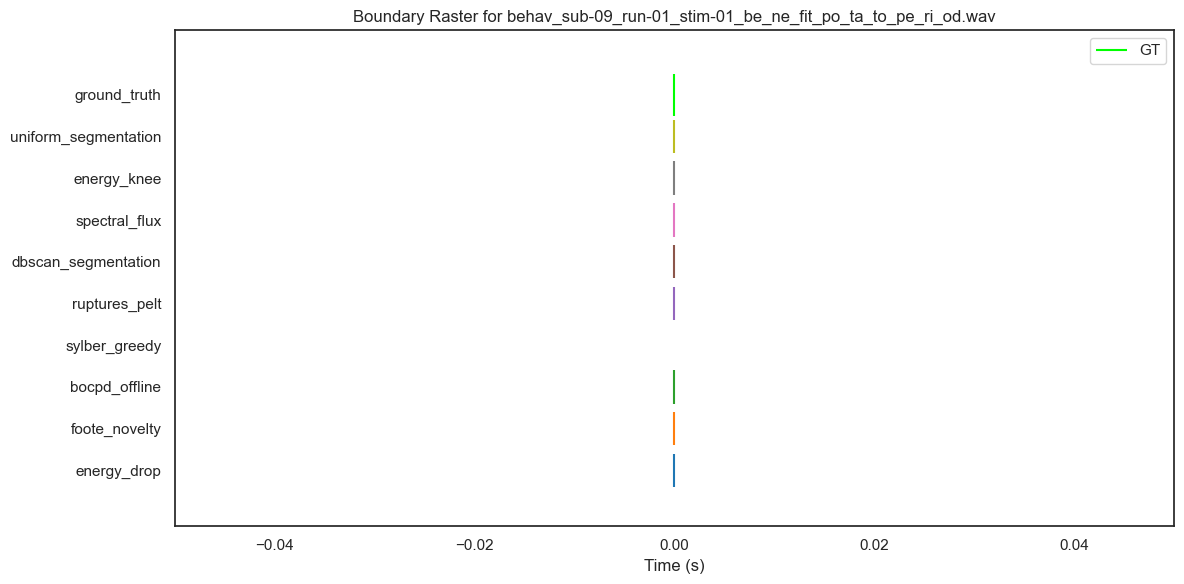

In [63]:
# pick the clip you want to inspect
clip_idx = 0
wav_path, ref_times, wav_signal, states = clips[clip_idx]

# build a list of (algo_name, boundary_times) pairs
data = []
for algo in all_algos:
    # choose the right input (raw audio vs. feature‐states)
    inp = wav_signal if algo in AUDIO_ALGOS else states

    # grab tuned params or empty dict
    if algo in tuned_algos:
        row = best_df[best_df.algo == algo].iloc[0]
        params = {c:int(row[c]) if c in _int_params else row[c]
                  for c in row.index
                  if c not in ["algo","f_mean","f_std","t_mean","mem_mean"]
                     and not pd.isna(row[c])}
    else:
        params = {}

    # get its segments and convert to times
    segs = _cutters.run_cut_method(algo, inp, **params)
    times = _eval.frames_to_times(segs)
    data.append((algo, times))

# now make the eventplot
fig, ax = plt.subplots(figsize=(12, 6))

# extract just the list of times
times_list = [t for _, t in data]
labels     = [a for a, _ in data]

cmap = plt.get_cmap("tab10")
N = len(labels)   # number of algorithm rows
colors = [cmap(i / N) for i in range(N)]

ax.eventplot(
    times_list,
    orientation="horizontal",
    lineoffsets=np.arange(N),
    linelengths=0.8,
    colors=colors
)

# overlay GT in a contrasting color on a separate row at top
ax.eventplot([ref_times],
             orientation='horizontal',
             lineoffsets=[len(labels)],
             linelengths=1.0,
             colors=['lime'],
             label='GT')

# y‐axis ticks
full_dur = len(wav_signal)/sr
ax.set_xlim(0, full_dur)
ax.set_yticks(np.arange(len(labels)+1))
ax.set_yticklabels(labels + ['ground_truth'])
ax.set_xlabel("Time (s)")
ax.set_title(f"Boundary Raster for {wav_path.name}")
ax.set_xlim(0, _eval.frames_to_times([(0,len(states))]).max())  # full duration

# legend only for GT
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [69]:
dur = len(wav_signal) / sr
print(f"Clip duration: {dur:.2f} seconds")

Clip duration: 12.40 seconds


Clip duration: 4.50 s


/opt/homebrew/Caskroom/miniconda/base/envs/sylber/lib/python3.10/site-packages/bayesian_changepoint_detection/offline_changepoint_detection.py:97: RuntimeWarning: invalid value encountered in log
  antiG = np.log(-G[n-1-t])


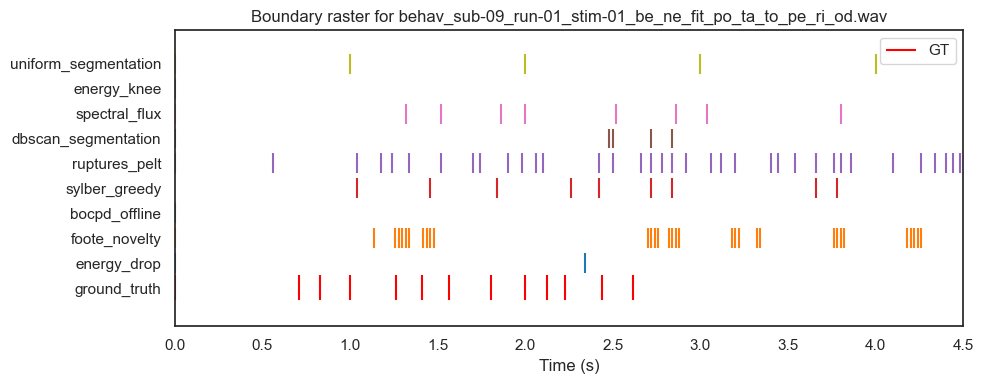

In [76]:
# pick one clip
wav_path, ref_times, wav_signal, states = clips[0]
# if you still don’t have sr in scope, re-load it:
_, sr = librosa.load(str(wav_path), sr=None)
duration = librosa.get_duration(y=wav_signal, sr=sr)
print(f"Clip duration: {duration:.2f} s")

# build a dict of tuned rows from your best-params CSV
tuned = { row.algo: row for _, row in best_df.iterrows() }

# which cutters to run
all_algos = [
    "energy_drop","foote_novelty","bocpd_offline","sylber_greedy",
    "ruptures_pelt","dbscan_segmentation","spectral_flux",
    "energy_knee","uniform_segmentation"
]

# set of keys that must be ints
_int_keys = {
    "ker_win","min_len","seg_len",
    "lam","penalty","min_size","jump","min_samples"
}

data = []
for algo in all_algos:
    # get that algo’s tuned row if any
    if algo in tuned:
        row = tuned[algo]
        params = {
            k: row[k]
            for k in row.index
            if k not in ("algo","f_mean","f_std","t_mean","mem_mean")
               and pd.notna(row[k])
        }
    else:
        params = {}

    # cast integer parameters
    for k in list(params):
        if k in _int_keys:
            params[k] = int(params[k])

    # choose input: raw‐wave for spectral_flux, else frames
    inp = wav_signal if algo=="spectral_flux" else states

    # run it
    segs, t_sec, mem_mb = _eval.run_algo(
        lambda st, a=algo, p=params: 
            _cutters.run_cut_method(a, st, **p),
        inp
    )

    # convert to times
    times = _eval.frames_to_times(segs)
    data.append((algo, times))

# now plot
fig, ax = plt.subplots(figsize=(10,4))
labels     = [a for a,_ in data]
times_list = [t for _,t in data]
n          = len(labels)

# one distinct color per algo
palette = plt.get_cmap("tab10").colors
colors  = [palette[i % len(palette)] for i in range(n)]

ax.eventplot(
    times_list,
    orientation="horizontal",
    lineoffsets=np.arange(n),
    linelengths=0.8,
    colors=colors
)

# overlay ground truth (in red) on its own row below all algos
ax.eventplot(
    [ref_times],
    orientation="horizontal",
    lineoffsets=[-1],
    linelengths=1.0,
    colors=["red"],
    label="GT"
)

# label rows
ax.set_yticks(np.arange(-1, n))
ax.set_yticklabels(["ground_truth"] + labels)

# force x-axis to clip’s true duration
ax.set_xlim(0, duration)
ax.set_xlabel("Time (s)")
ax.set_title(f"Boundary raster for {wav_path.name}")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()